In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import CoolTrack modules
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_and_clean_grid_pandas
from cooltrack.models import ThermalEvolutionModels

# Plotting style
sns.set_theme(style="whitegrid", context="talk")

# Data Path
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet"

In [2]:
print("Loading data...")
# Load the data using our optimized PyArrow loader
df = load_and_clean_grid_pandas(GRID_FILE_PATH)

# For rapid evaluation testing, we can use a slice or the full dataset.
# Let's use the full loaded dataset here.
print(f"Data loaded successfully! Shape: {df.shape}")

2026-02-23 02:30:12,505 - INFO - Loading filtered parquet file: ../data/HADES_grid/hades_processed_grid.parquet...


Loading data...


2026-02-23 02:30:12,744 - INFO - Grid loaded successfully. Final shape: (91613, 13)


Data loaded successfully! Shape: (91613, 13)


In [3]:
print("Training models and cleaning data...")
ml_engine = ThermalEvolutionModels()

# Capture the cleaned dataframe that the model returns!
df_clean = ml_engine.train_models(df, tune_hyperparameters=False, clean_outliers=True)

# NOW split the test sets using the CLEANED data
X_tint = df_clean[INDEPENDENT_DIMS + ['S_physical']]
y_tint = df_clean['T_int']
_, X_tint_test, _, y_tint_test = train_test_split(X_tint, y_tint, test_size=0.2, random_state=42)

X_dsdt = df_clean[INDEPENDENT_DIMS + ['S_physical', 'T_int']]
y_dsdt = df_clean['abs_log_dsdt']
_, X_dsdt_test, _, y_dsdt_test = train_test_split(X_dsdt, y_dsdt, test_size=0.2, random_state=42)

# Generate predictions on the unseen CLEAN test data
tint_preds = ml_engine.tint_model.predict(X_tint_test)
dsdt_preds = ml_engine.dsdt_model.predict(X_dsdt_test)
print("Predictions generated on clean data!")

2026-02-23 02:30:14,768 - INFO - Performing first-pass training to identify grid outliers...


Training models and cleaning data...


2026-02-23 02:30:15,412 - INFO - Dropping 1834 corrupted grid points (> 1.0 dex error).
2026-02-23 02:30:15,435 - INFO - Training final T_int state model...
2026-02-23 02:30:17,210 - INFO - Final T_int R^2: 0.9645
2026-02-23 02:30:17,226 - INFO - Training final baseline dS/dt model...
2026-02-23 02:30:19,699 - INFO - Final dS/dt test R^2: 0.9951


Predictions generated on clean data!


In [4]:
print("=== T_int Model Evaluation ===")
print(f"R^2 Score: {r2_score(y_tint_test, tint_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_tint_test, tint_preds):.2f} K")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_tint_test, tint_preds)):.2f} K")

print("\n=== dS/dt Model Evaluation (Log10 scale) ===")
print(f"R^2 Score: {r2_score(y_dsdt_test, dsdt_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_dsdt_test, dsdt_preds):.4f} dex")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_dsdt_test, dsdt_preds)):.4f} dex")

=== T_int Model Evaluation ===
R^2 Score: 0.9648
Mean Absolute Error (MAE): 31.83 K
Root Mean Squared Error (RMSE): 59.33 K

=== dS/dt Model Evaluation (Log10 scale) ===
R^2 Score: 0.9951
Mean Absolute Error (MAE): 0.0335 dex
Root Mean Squared Error (RMSE): 0.0866 dex


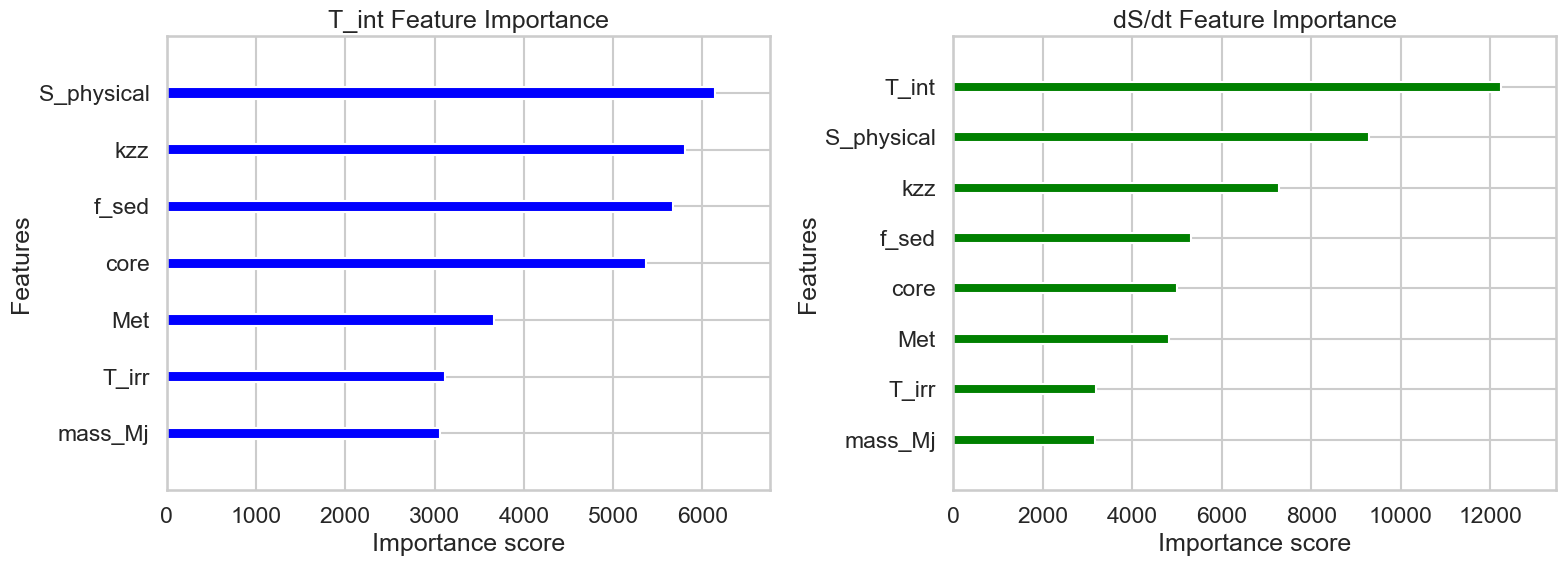

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# T_int Feature Importances
xgb.plot_importance(ml_engine.tint_model, ax=axes[0], importance_type='weight', 
                    title='T_int Feature Importance', color='blue', show_values=False)
axes[0].set_yticklabels(X_tint_test.columns)

# dS/dt Feature Importances
xgb.plot_importance(ml_engine.dsdt_model, ax=axes[1], importance_type='weight', 
                    title='dS/dt Feature Importance', color='green', show_values=False)
axes[1].set_yticklabels(X_dsdt_test.columns)

plt.tight_layout()
plt.show()

=== The Top 10 Worst Predictions ===


,mass_Mj,T_int,True_log_dsdt,Pred_log_dsdt,Error_dex
36262,0.389129,967.296640,-12.686212,-8.682642,4.003570
33931,0.353175,939.144410,-10.939176,-8.150162,2.789015
12035,15.153691,732.814409,-15.135264,-12.499296,2.635968
36318,0.389804,995.807106,-12.516499,-10.022720,2.493779
62066,0.570580,252.298707,-9.670849,-11.398355,1.727505
81122,0.774290,1540.084999,-8.616377,-10.235963,1.619586
79352,0.746945,434.364384,-9.952736,-11.455732,1.502996
300,0.043392,1078.600753,-6.636581,-8.132648,1.496067
24006,4.149040,83.592569,-15.318719,-13.825027,1.493691
32698,0.347803,988.001251,-8.070516,-9.546874,1.476358


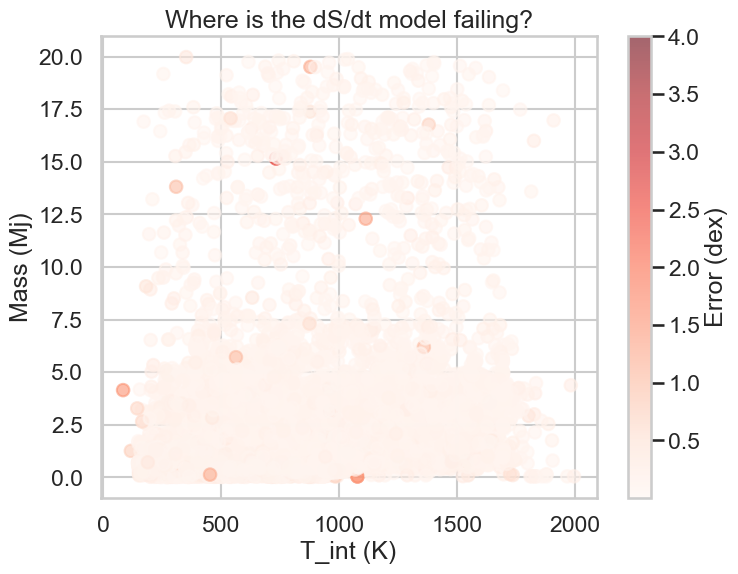

In [6]:
# Calculate absolute errors
dsdt_errors = np.abs(y_dsdt_test - dsdt_preds)

# Attach errors back to the test dataframe
error_df = X_dsdt_test.copy()
error_df['True_log_dsdt'] = y_dsdt_test
error_df['Pred_log_dsdt'] = dsdt_preds
error_df['Error_dex'] = dsdt_errors

# Sort by the worst errors
worst_offenders = error_df.sort_values(by='Error_dex', ascending=False)

print("=== The Top 10 Worst Predictions ===")
display(worst_offenders[['mass_Mj', 'T_int', 'True_log_dsdt', 'Pred_log_dsdt', 'Error_dex']].head(10))

# Plot where the errors are happening
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(error_df['T_int'], error_df['mass_Mj'], c=error_df['Error_dex'], cmap='Reds', alpha=0.6)
plt.colorbar(scatter, label='Error (dex)')
ax.set_xlabel('T_int (K)')
ax.set_ylabel('Mass (Mj)')
ax.set_title('Where is the dS/dt model failing?')
plt.show()